# Chronos-2 — Test local en CPU
Verifica que `amazon/chronos-2` (120M) funcione correctamente sin GPU.

## 1. Verificar entorno

In [7]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import sys
import torch
import chronos

print(f"Python:  {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"Chronos: {chronos.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"Dispositivo a usar: CPU")

Python:  3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
PyTorch: 2.11.0+cpu
Chronos: 2.2.2
CUDA disponible: False
Dispositivo a usar: CPU


## 2. Cargar el modelo

In [8]:
from chronos import Chronos2Pipeline

pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    device_map="cpu",
    torch_dtype=torch.bfloat16,
)

print("Modelo cargado correctamente.")

Modelo cargado correctamente.


## 3. Forecasting univariado simple

In [9]:
import numpy as np
import pandas as pd

# Serie sintética: tendencia + estacionalidad semanal + ruido
np.random.seed(42)
n = 90
t = np.arange(n)
valores = 100 + 0.5 * t + 10 * np.sin(2 * np.pi * t / 7) + np.random.normal(0, 3, n)

df = pd.DataFrame({
    "item_id": "serie_test",
    "timestamp": pd.date_range("2024-01-01", periods=n, freq="D"),
    "target": valores,
})

df.tail()

,item_id,timestamp,target
85,serie_test,2024-03-26,148.813044
86,serie_test,2024-03-27,155.495485
87,serie_test,2024-03-28,148.825091
88,serie_test,2024-03-29,138.071882
89,serie_test,2024-03-30,136.290523


In [10]:
predicciones = pipeline.predict_df(
    df,
    prediction_length=14,
    quantile_levels=[0.1, 0.5, 0.9],
    batch_size=8,
)

predicciones

,item_id,timestamp,target_name,predictions,0.1,0.5,0.9
0,serie_test,2024-03-31,target,137.0,134.0,137.0,140.0
1,serie_test,2024-04-01,target,144.0,141.0,144.0,147.0
2,serie_test,2024-04-02,target,153.0,149.0,153.0,156.0
3,serie_test,2024-04-03,target,157.0,153.0,157.0,160.0
4,serie_test,2024-04-04,target,152.0,149.0,152.0,156.0
5,serie_test,2024-04-05,target,144.0,141.0,144.0,148.0
6,serie_test,2024-04-06,target,139.0,136.0,139.0,142.0
7,serie_test,2024-04-07,target,140.0,137.0,140.0,143.0
8,serie_test,2024-04-08,target,147.0,144.0,147.0,151.0
9,serie_test,2024-04-09,target,157.0,152.0,157.0,161.0


## 4. Visualizar resultado

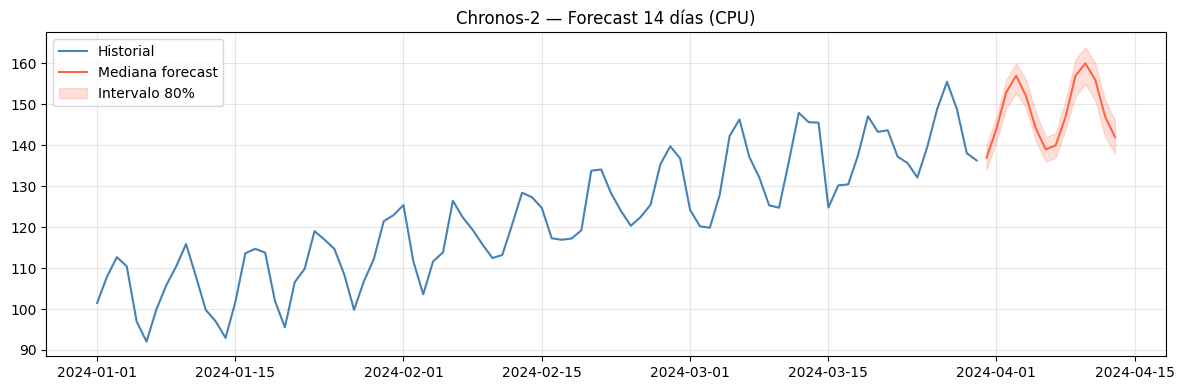

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))

# Historial
ax.plot(df["timestamp"], df["target"], label="Historial", color="steelblue")

# Forecast
ax.plot(predicciones["timestamp"], predicciones["0.5"], label="Mediana forecast", color="tomato")
ax.fill_between(
    predicciones["timestamp"],
    predicciones["0.1"],
    predicciones["0.9"],
    alpha=0.2,
    color="tomato",
    label="Intervalo 80%",
)

ax.set_title("Chronos-2 — Forecast 14 días (CPU)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Test con covariables

In [12]:
# df_cov: historial con la covariable como columna extra
df_cov = df.copy()
df_cov["dia_semana"] = df_cov["timestamp"].dt.dayofweek.astype(float)

# future_df: solo las filas futuras con la covariable conocida (sin target)
fechas_futuras = pd.date_range(
    df_cov["timestamp"].max() + pd.Timedelta(days=1), periods=14, freq="D"
)
future_df = pd.DataFrame({
    "item_id": "serie_test",
    "timestamp": fechas_futuras,
    "dia_semana": fechas_futuras.dayofweek.astype(float),
})

pred_cov = pipeline.predict_df(
    df=df_cov,
    future_df=future_df,
    prediction_length=14,
    quantile_levels=[0.1, 0.5, 0.9],
    batch_size=8,
)

print("Forecast con covariable completado.")
pred_cov

Forecast con covariable completado.


,item_id,timestamp,target_name,predictions,0.1,0.5,0.9
0,serie_test,2024-03-31,target,137.0,133.0,137.0,140.0
1,serie_test,2024-04-01,target,144.0,140.0,144.0,147.0
2,serie_test,2024-04-02,target,153.0,149.0,153.0,156.0
3,serie_test,2024-04-03,target,155.0,151.0,155.0,158.0
4,serie_test,2024-04-04,target,151.0,147.0,151.0,154.0
5,serie_test,2024-04-05,target,143.0,139.0,143.0,146.0
6,serie_test,2024-04-06,target,138.0,135.0,138.0,142.0
7,serie_test,2024-04-07,target,140.0,136.0,140.0,144.0
8,serie_test,2024-04-08,target,147.0,142.0,147.0,151.0
9,serie_test,2024-04-09,target,156.0,151.0,156.0,160.0


---
Si todas las celdas corrieron sin errores, el entorno está configurado correctamente.